In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import ks_2samp
import random
import math
import sklearn.mixture as mix
import astropy.visualization.hist

bins100 = np.append(np.sort(x)[::100], np.max(x)) --> [::100] means one data each 100

considering mu = 1 means to have the masses in unit of mu (an you can rescale it in solarmass or wathever you need)

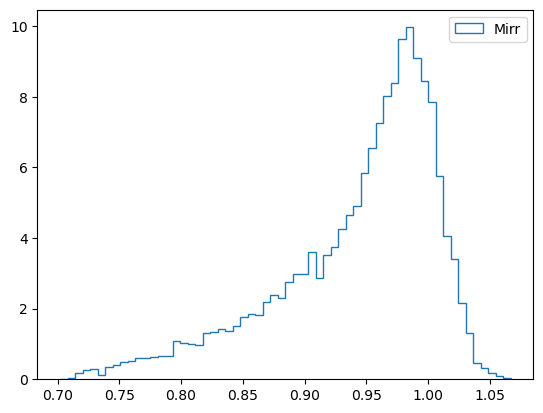

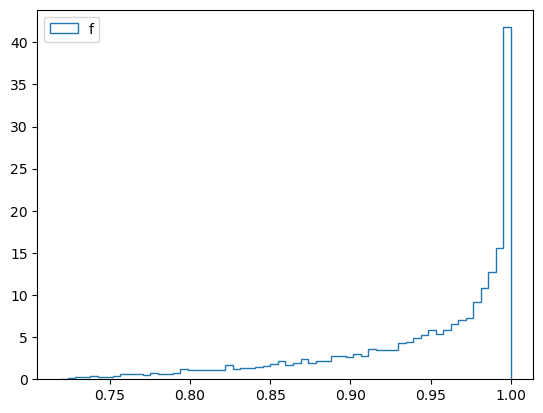

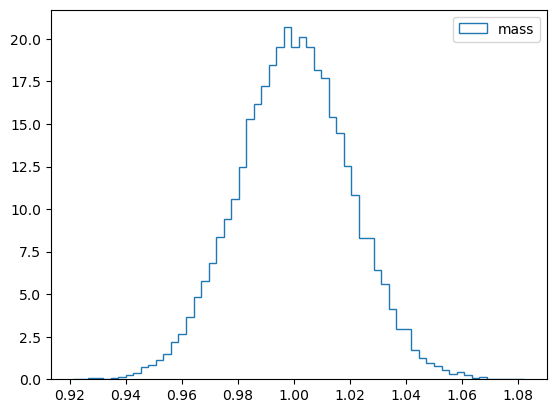

In [2]:
mu = 1
sigma = 0.02
N = 10000
spin = np.random.uniform(0, 1, N)
mass = np.random.normal(mu, sigma, N)

def f(x):
    return np.sqrt((1+np.sqrt(1-x**2))/2)
    
Mirr = mass*f(spin)

a,b,c = plt.hist(Mirr, bins=60, density=True, histtype="step", label='Mirr')
plt.legend()
plt.show()
plt.hist(f(spin), bins=60, density=True, histtype="step", label='f')
plt.legend()
plt.show()
plt.hist(mass, bins=60, density=True, histtype="step", label='mass')
plt.legend()
plt.show()

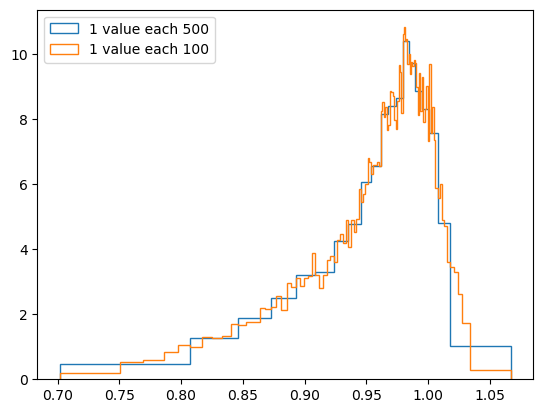

In [4]:
#same number of objets in each bin
bins500 = np.append(np.sort(Mirr)[::500], np.max(Mirr)) 
bins100 = np.append(np.sort(Mirr)[::100], np.max(Mirr))
plt.hist(Mirr, bins=bins500, density=True, histtype="step", label = '1 value each 500') 
plt.hist(Mirr, bins=bins100, density=True, histtype="step", label = '1 value each 100')
plt.legend()

# KDE

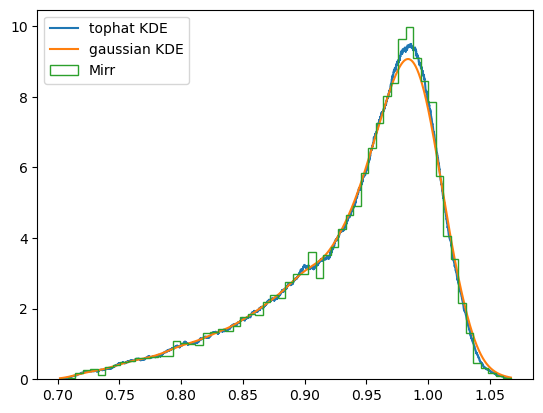

In [5]:
from sklearn.neighbors import KernelDensity
xgrid = np.linspace(Mirr.min(),Mirr.max(),N)

def kde_sklearn(data, x, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFtophat = kde_sklearn(Mirr,xgrid,bandwidth=0.01,kernel="tophat")
PDFgauss = kde_sklearn(Mirr,xgrid,bandwidth=0.01,kernel="gaussian")
plt.plot(xgrid,PDFtophat, label="tophat KDE")
plt.plot(xgrid,PDFgauss, label="gaussian KDE")
a,b,c = plt.hist(Mirr, bins=60, density=True, histtype="step",label='Mirr')
plt.legend()

## different bandwidths

In [ ]:
PDFgauss_1 = kde_sklearn(Mirr,xgrid,bandwidth=0.1,kernel="gaussian")
PDFgauss_2 = kde_sklearn(Mirr,xgrid,bandwidth=0.01,kernel="gaussian")
PDFgauss_3 = kde_sklearn(Mirr,xgrid,bandwidth=0.001,kernel="gaussian")
plt.plot(xgrid,PDFgauss_1,label='bw=0.1')
plt.plot(xgrid,PDFgauss_2,label='bw=0.01')
plt.plot(xgrid,PDFgauss_3,label='bw=0.001')
a,b,c = plt.hist(Mirr, bins=60, density=True, histtype="step")
plt.xlabel('Mirr')
plt.legend()

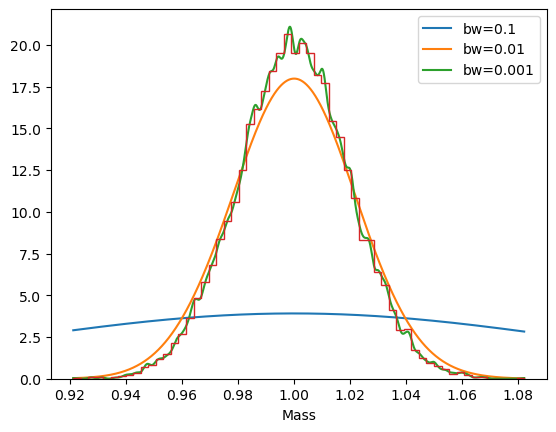

In [12]:
PDFgauss_1 = kde_sklearn(mass,np.linspace(mass.min(),mass.max(),N),bandwidth=0.1,kernel="gaussian")
PDFgauss_2 = kde_sklearn(mass,np.linspace(mass.min(),mass.max(),N),bandwidth=0.01,kernel="gaussian")
PDFgauss_3 = kde_sklearn(mass,np.linspace(mass.min(),mass.max(),N),bandwidth=0.001,kernel="gaussian")
plt.plot(np.linspace(mass.min(),mass.max(),N),PDFgauss_1,label='bw=0.1')
plt.plot(np.linspace(mass.min(),mass.max(),N),PDFgauss_2,label='bw=0.01')
plt.plot(np.linspace(mass.min(),mass.max(),N),PDFgauss_3,label='bw=0.001')
a,b,c = plt.hist(mass, bins=60, density=True, histtype="step")
plt.xlabel('Mass')
plt.legend()

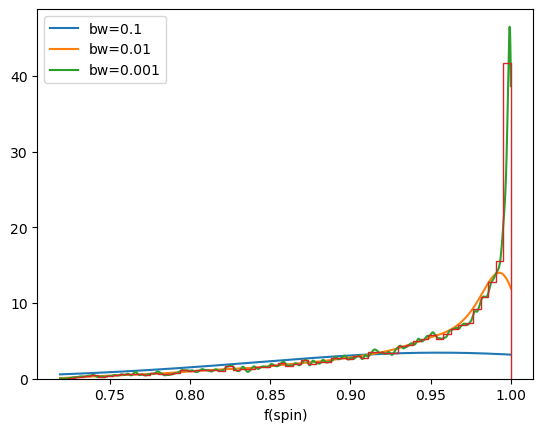

In [14]:
PDFgauss_1 = kde_sklearn(f(spin),np.linspace(f(spin).min(),f(spin).max(),N),bandwidth=0.1,kernel="gaussian")
PDFgauss_2 = kde_sklearn(f(spin),np.linspace(f(spin).min(),f(spin).max(),N),bandwidth=0.01,kernel="gaussian")
PDFgauss_3 = kde_sklearn(f(spin),np.linspace(f(spin).min(),f(spin).max(),N),bandwidth=0.001,kernel="gaussian")
plt.plot(np.linspace(f(spin).min(),f(spin).max(),N),PDFgauss_1,label='bw=0.1')
plt.plot(np.linspace(f(spin).min(),f(spin).max(),N),PDFgauss_2,label='bw=0.01')
plt.plot(np.linspace(f(spin).min(),f(spin).max(),N),PDFgauss_3,label='bw=0.001')
a,b,c = plt.hist(f(spin), bins=60, density=True, histtype="step")
plt.xlabel('f(spin)')
plt.legend()

# KD test

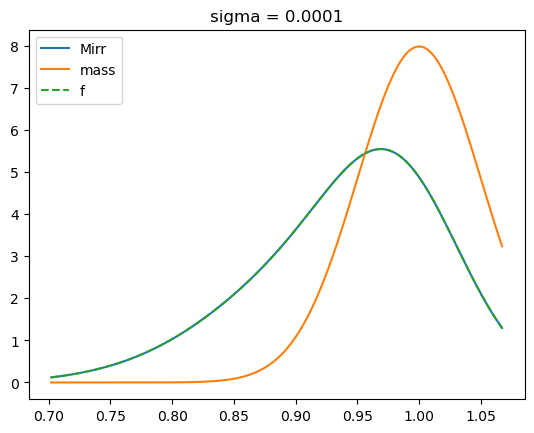

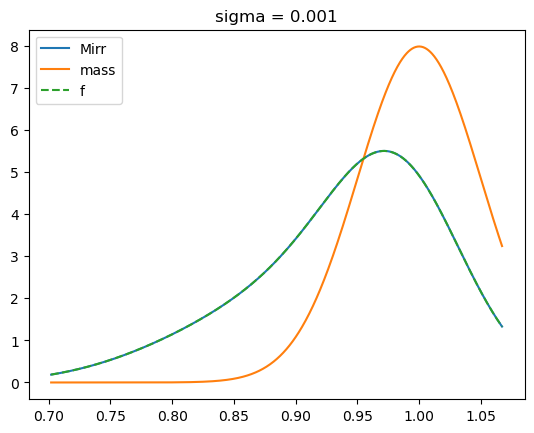

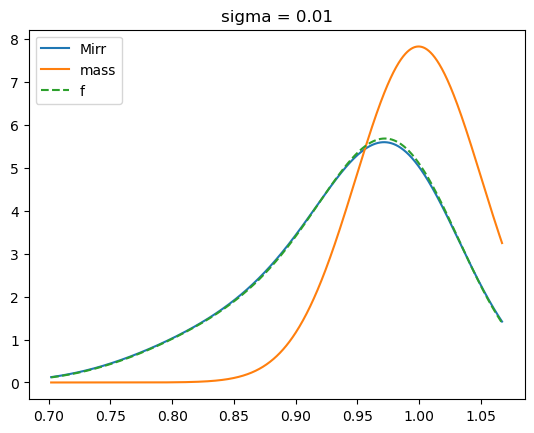

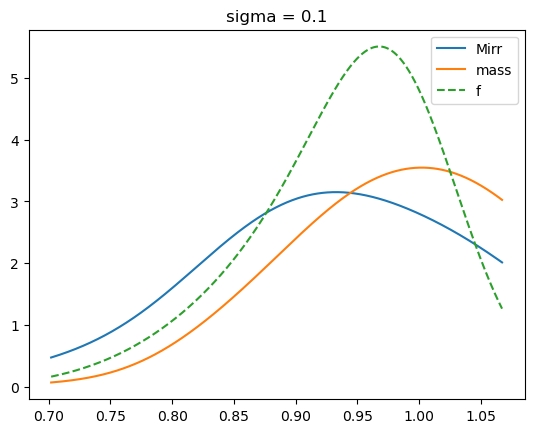

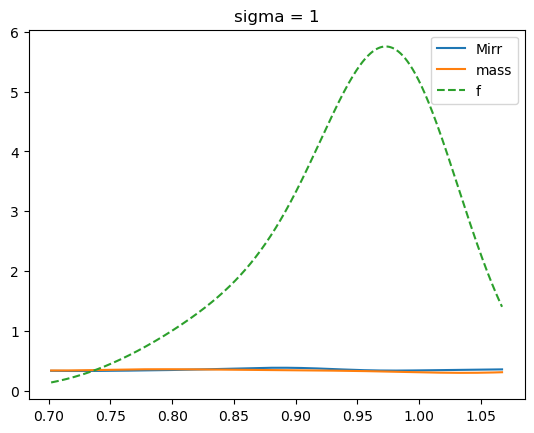

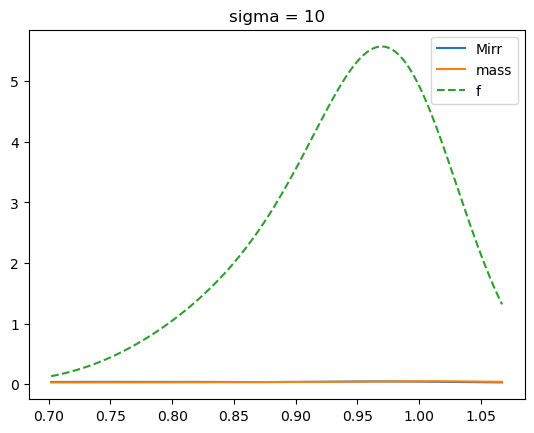

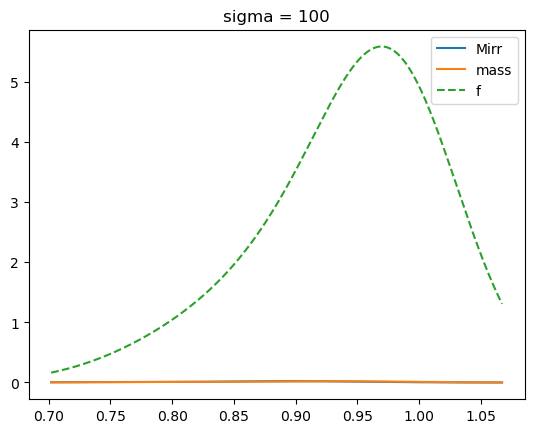

In [21]:
sigma_n = (0.0001,0.001,0.01,0.1,1,10,100)
#(np.geomspace) al posto di np.linspace! meglio
pvalues1 = []
pvalues2 = []

for i in sigma_n:
    spin_n = np.random.uniform(0, 1, 1000)
    mass_n = np.random.normal(mu, i, 1000)
    Mirr_n = mass_n*f(spin_n)
    
    pvalues1.append(ks_2samp(Mirr_n, f(spin_n)).statistic)
    pvalues2.append(ks_2samp(Mirr_n, mass_n).statistic)

    PDFgauss_Mirr = kde_sklearn(Mirr_n,np.linspace(Mirr.min(),Mirr.max(),1000),bandwidth=0.05,kernel="gaussian")
    PDFgauss_mass = kde_sklearn(mass_n,np.linspace(Mirr.min(),Mirr.max(),1000),bandwidth=0.05,kernel="gaussian")
    PDFgauss_f = kde_sklearn(f(spin_n),np.linspace(Mirr.min(),Mirr.max(),1000),bandwidth=0.05,kernel="gaussian")
    
    plt.plot(np.linspace(Mirr.min(),Mirr.max(),1000), PDFgauss_Mirr, label='Mirr')
    plt.plot(np.linspace(Mirr.min(),Mirr.max(),1000), PDFgauss_mass, label='mass')
    plt.plot(np.linspace(Mirr.min(),Mirr.max(),1000), PDFgauss_f, '--', label='f')
    plt.legend()
    plt.title(f"sigma = {i}")
    plt.show()

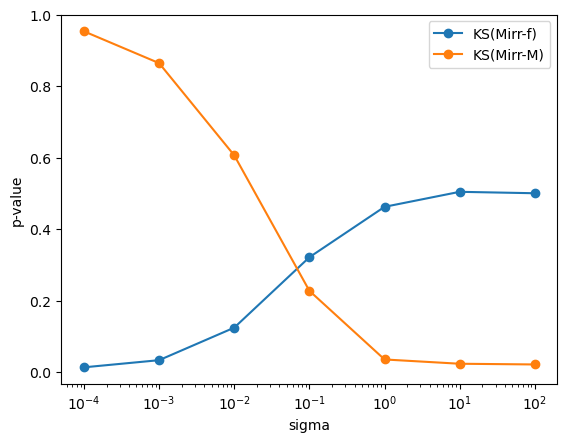

In [22]:
plt.plot(sigma_n , pvalues1, '-o', label='KS(Mirr-f)')
plt.plot(sigma_n , pvalues2, '-o', label='KS(Mirr-M)')
plt.xscale('log')
plt.xlabel('sigma')
plt.ylabel('p-value')
plt.legend()

# Mirr analitic pdf and KDE comparison

In [23]:
import scipy.integrate as spi

mu = 1
sigma = 0.02

def pdfMirr(f, Mirr):
    return np.exp(-(((Mirr/f)-mu)**2)/(2*sigma**2)) * (((2*f**2)-1)/(f*((1-f**2)**0.5)))

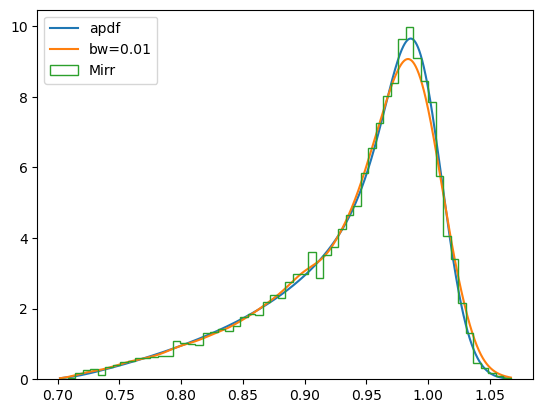

In [24]:
apdf_Mirr = []
f_arr = np.array(f(spin))
Mirr_ORDINATO = np.sort(Mirr)
for i in range(len(f_arr)):
    I = spi.quad(pdfMirr,1/2**0.5, 1, args=Mirr_ORDINATO[i])
    apdf_Mirr.append(I[0] * (((2/np.pi)**0.5)/sigma))

plt.plot(Mirr_ORDINATO,apdf_Mirr,label='apdf')
PDF_Mirr = kde_sklearn(Mirr,np.linspace(Mirr.min(),Mirr.max(),N),bandwidth=0.01,kernel="gaussian")
plt.plot(xgrid,PDF_Mirr,label='bw=0.01')
a,b,c = plt.hist(Mirr, bins=60, density=True, histtype="step", label='Mirr')
plt.legend()

# f analitic pdf and KDE comparison

In [25]:
def pif(f):
    return 2*((((2*f**2) - 1)/np.sqrt(1 - f**2)))

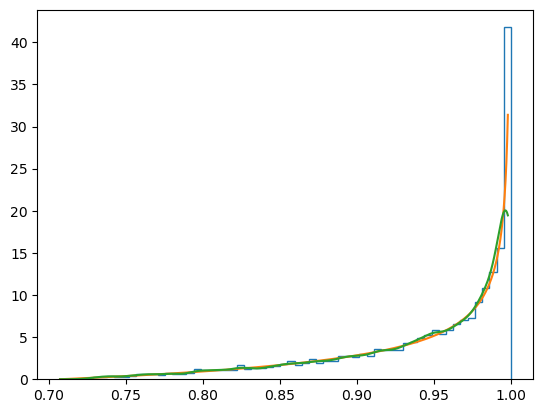

In [26]:
x_f = np.linspace(1/2**0.5,0.998,N)
PDFgaussf = kde_sklearn(f(spin),x_f,bandwidth=0.005,kernel="gaussian")
plt.hist(f(spin), bins=60, density=True, histtype="step")
plt.plot(x_f,pif(x_f))
plt.plot(x_f,PDFgaussf)